SVM (Linear)

First 5 Rows of Dataset:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Co

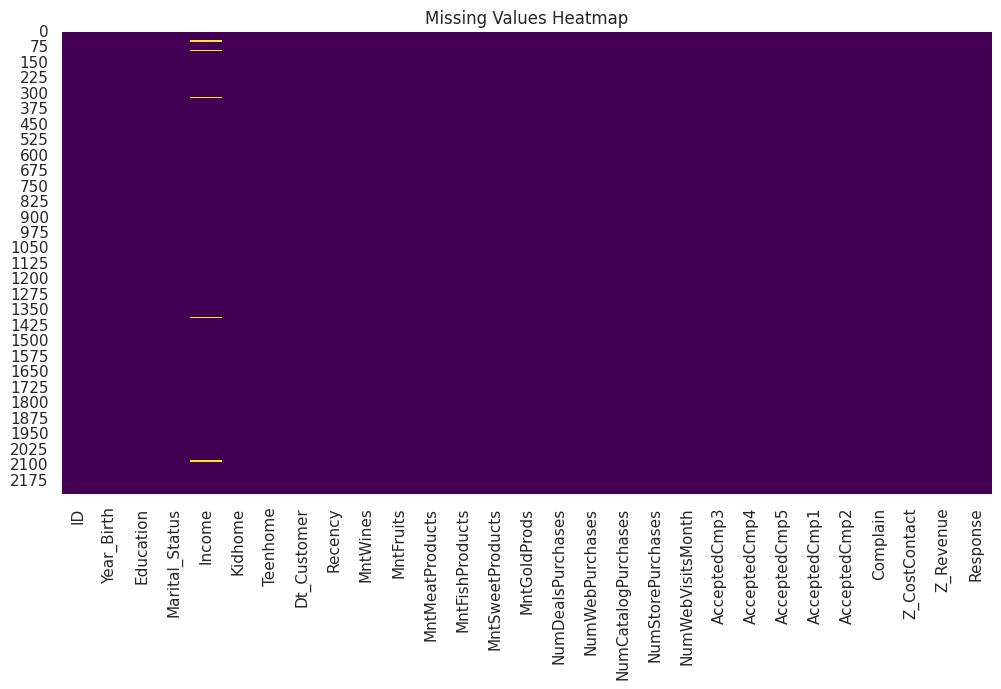


Missing Values After Imputation:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

Dataset After Dropping Columns:
   Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  Recency  \
0        1957  Graduation         Single  58138.0        0         0       58   
1        1954  Graduation        

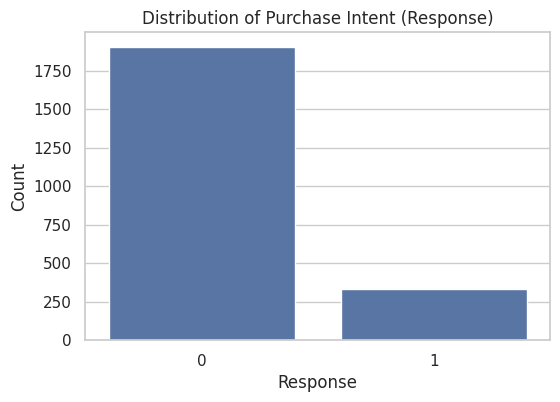

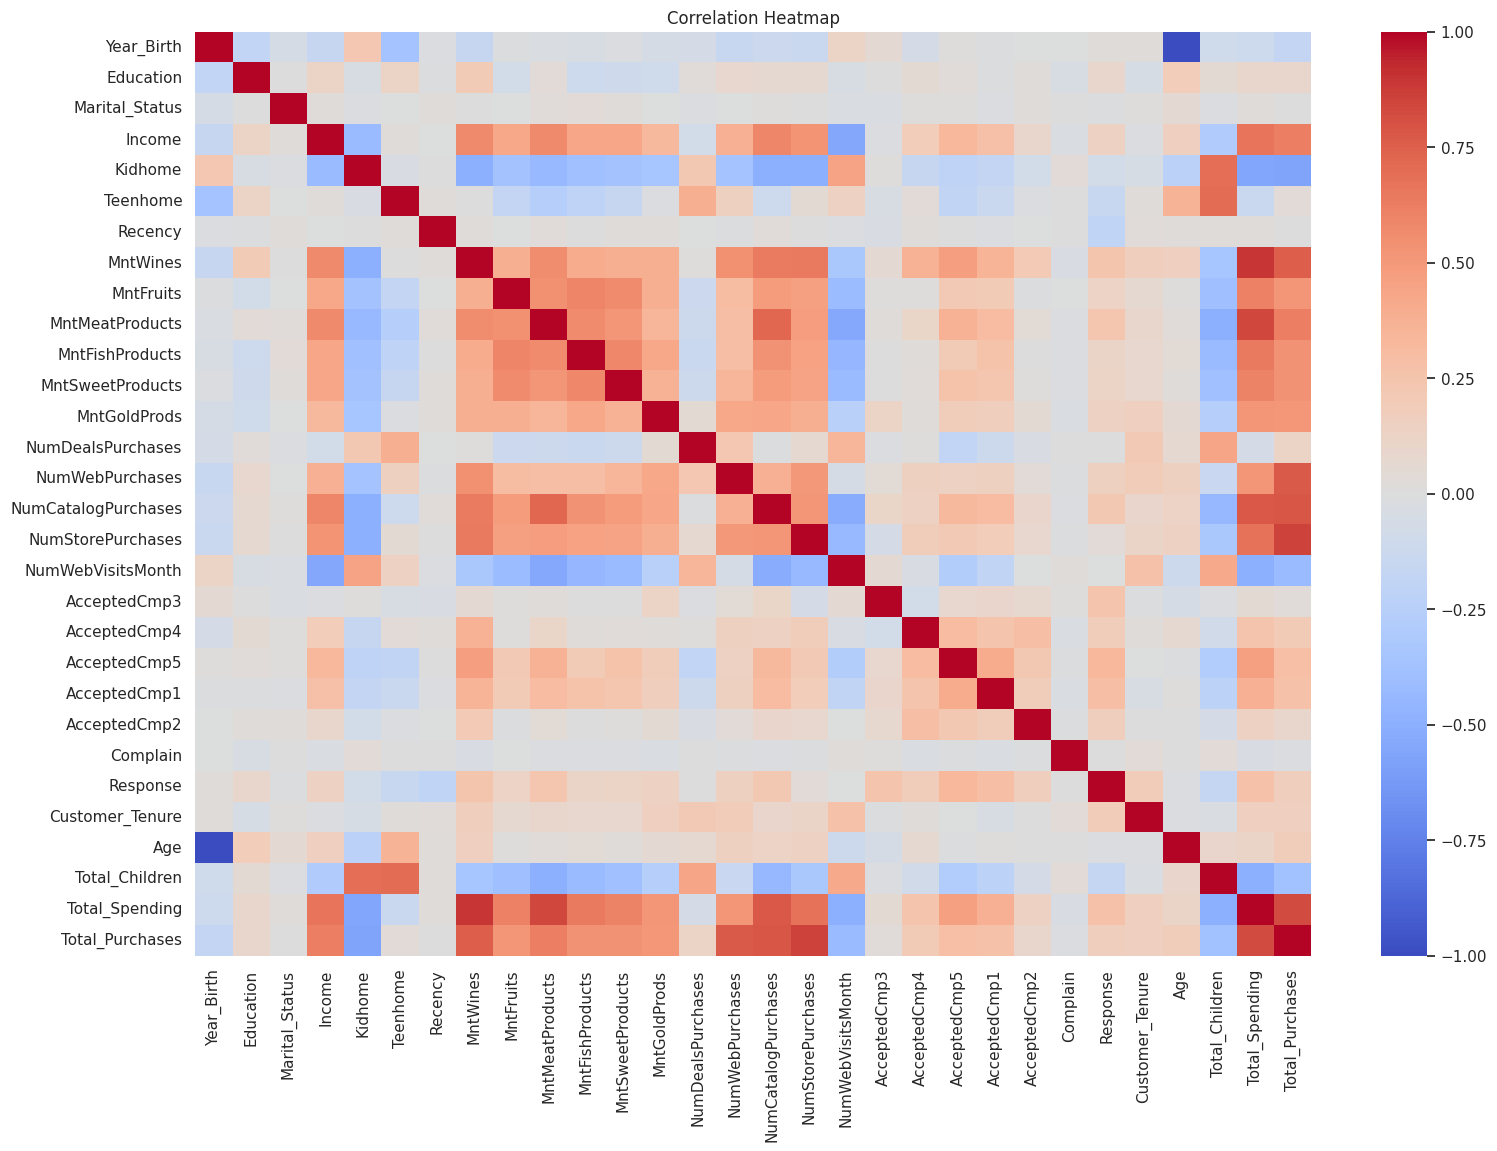

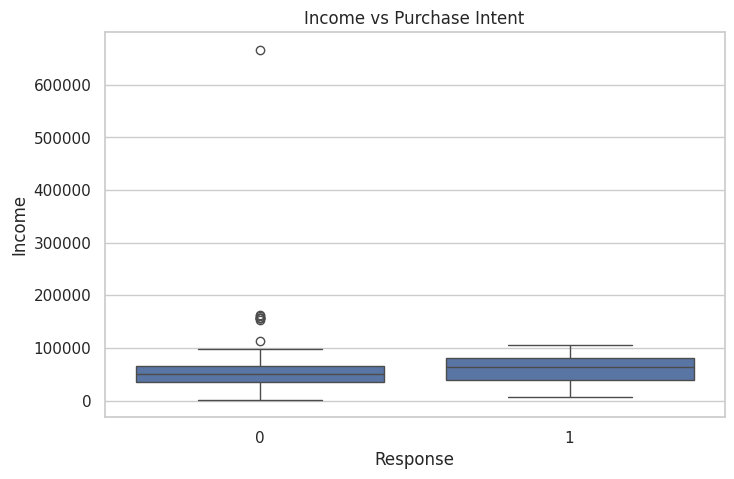

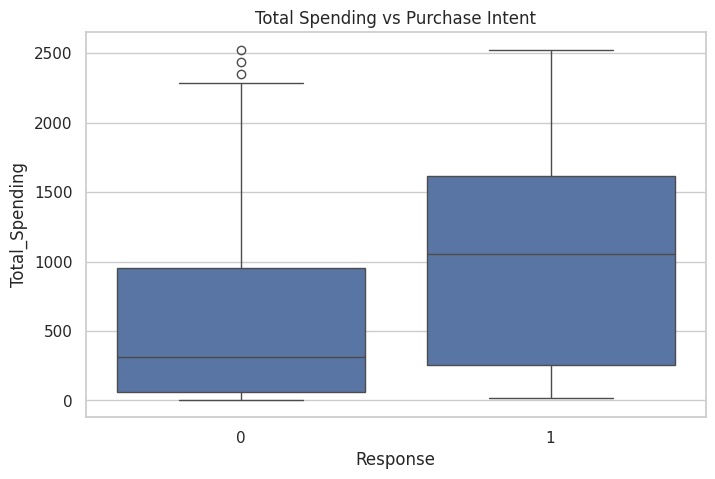

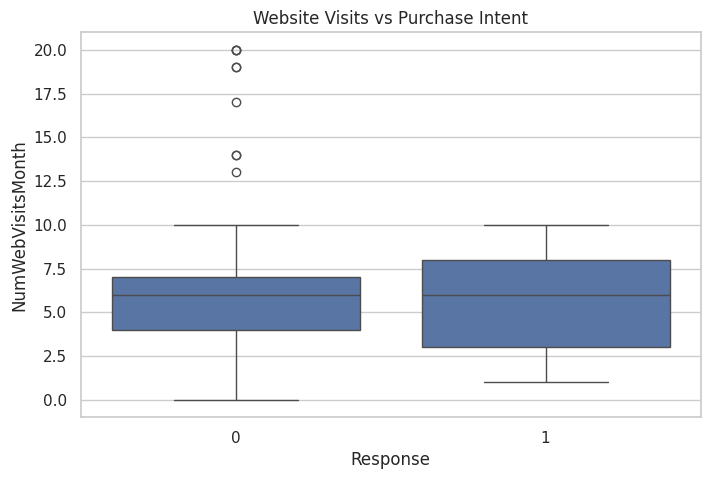


Feature Matrix Shape: (2237, 29)
Target Shape: (2237,)

Training Set Shape: (1789, 29)
Testing Set Shape: (448, 29)

SVM Model Training Completed

Accuracy: 0.8928571428571429
Precision: 0.8518518518518519
Recall: 0.34328358208955223
F1-Score: 0.48936170212765956
ROC-AUC Score: 0.8591295491048694
Kappa Score: 0.4413674858419494

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       381
           1       0.85      0.34      0.49        67

    accuracy                           0.89       448
   macro avg       0.87      0.67      0.71       448
weighted avg       0.89      0.89      0.87       448


Model Performance Metrics Table:
        Metric   Value
0     Accuracy  0.8929
1    Precision  0.8519
2       Recall  0.3433
3     F1-Score  0.4894
4      ROC-AUC  0.8591
5  Kappa Score  0.4414


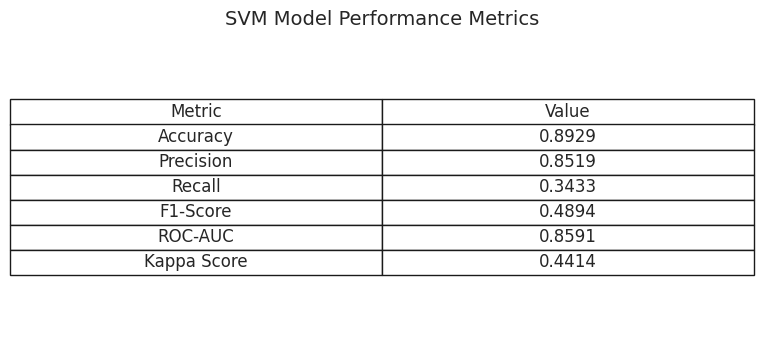

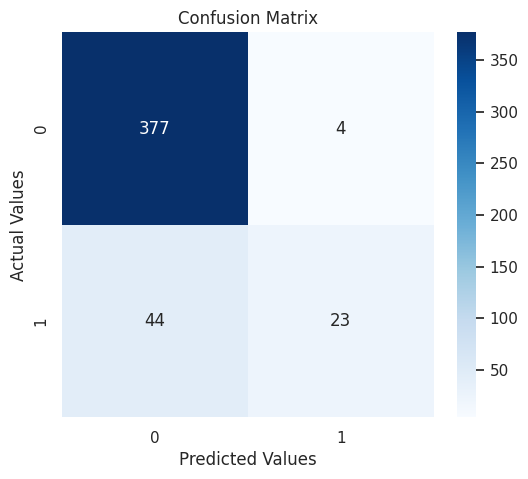

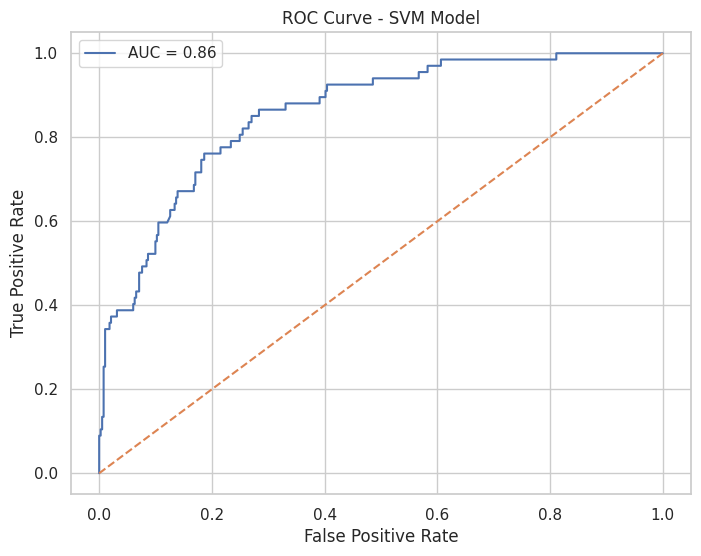


Top Important Features:
              Feature  Coefficient  Absolute_Coefficient
6             Recency    -0.439516              0.439516
24    Customer_Tenure     0.416122              0.416122
18       AcceptedCmp3     0.337886              0.337886
16  NumStorePurchases    -0.321494              0.321494
20       AcceptedCmp5     0.299851              0.299851
21       AcceptedCmp1     0.245819              0.245819
1           Education     0.218698              0.218698
19       AcceptedCmp4     0.182071              0.182071
5            Teenhome    -0.166477              0.166477
9     MntMeatProducts     0.163267              0.163267


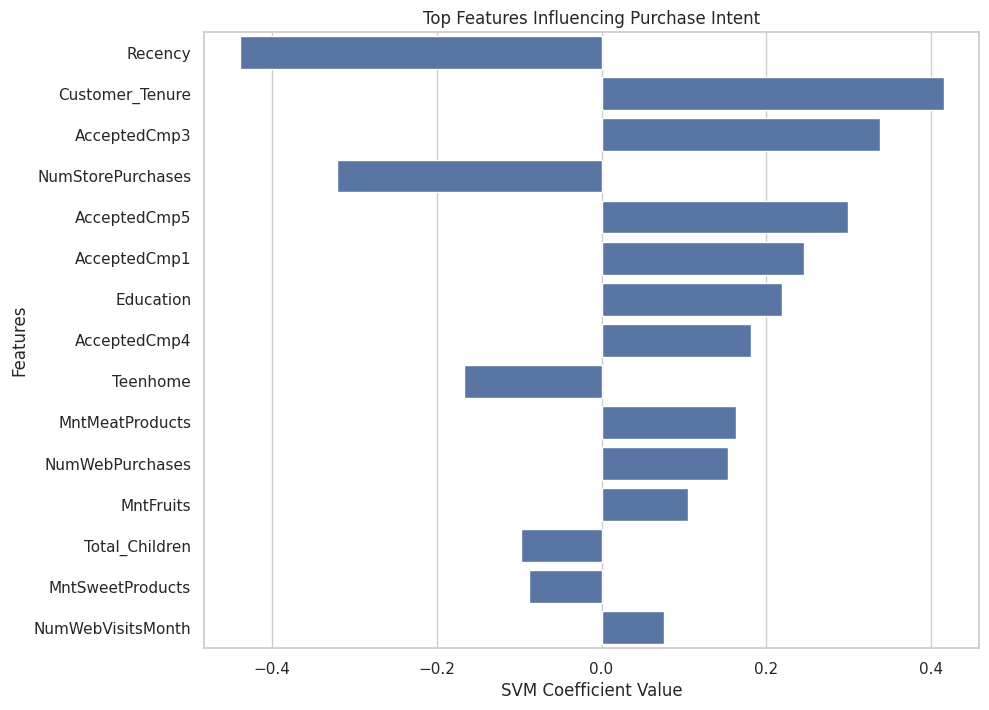


INTERPRETATION:
1. Positive coefficient -> increases purchase intent
2. Negative coefficient -> decreases purchase intent
3. Higher absolute coefficient -> stronger influence
4. Customer engagement variables like web visits,
   campaign acceptance, and total purchases
   help explain customer purchase intent.


In [ ]:
# SVM Model for Studying the Relationship Between Customer Engagement and Purchase Intent

# ## Research Topic

# **Studying the Relationship Between Customer Engagement and Purchase Intent**

# * Dependent Variable (Target): `Response`
# * Model Used: Support Vector Machine (SVM)
# * Kernel Used: Linear Kernel (`kernel='linear'`)
# * SMOTE: Not used

# ---

# # Step-by-Step Python Code

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Machine Learning
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set(style='whitegrid')


# ============================================================
# STEP 2: LOAD THE DATASET
# ============================================================

# Load dataset
file_path = '/content/marketing_campaign.xlsx'
df = pd.read_excel(file_path)

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumns in Dataset:")
print(df.columns)


# ============================================================
# STEP 3: BASIC DATA UNDERSTANDING
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# ============================================================
# STEP 4: CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# Visualizing missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


# ============================================================
# STEP 5: HANDLE MISSING VALUES
# ============================================================

# Income column has missing values
# Use median imputation because income may contain outliers

median_income = df['Income'].median()
df['Income'].fillna(median_income, inplace=True)

print("\nMissing Values After Imputation:")
print(df.isnull().sum())


# ============================================================
# STEP 6: FEATURE ENGINEERING
# ============================================================

# Convert Dt_Customer to datetime

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Create customer tenure feature
latest_date = df['Dt_Customer'].max()
df['Customer_Tenure'] = (latest_date - df['Dt_Customer']).dt.days

# Create age feature
current_year = 2026
df['Age'] = current_year - df['Year_Birth']

# Keep only customers aged 100 years or below

df = df[df["Age"] <= 100 ]

# Total children

df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Total spending

df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# Total purchases

df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)


# ============================================================
# STEP 7: DROP UNNECESSARY COLUMNS
# ============================================================

# ID is not useful for prediction
# Z_CostContact and Z_Revenue are constant columns
# Dt_Customer already transformed into tenure

columns_to_drop = ['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue']

df.drop(columns=columns_to_drop, inplace=True)

print("\nDataset After Dropping Columns:")
print(df.head())


# ============================================================
# STEP 8: ENCODE CATEGORICAL VARIABLES
# ============================================================

# Label Encoding categorical variables
label_encoder = LabelEncoder()

categorical_columns = ['Education', 'Marital_Status']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoded Dataset:")
print(df.head())


# ============================================================
# STEP 9: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# ------------------------------------------------------------
# 1. Target Variable Distribution
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Response', data=df)
plt.title('Distribution of Purchase Intent (Response)')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()


# ------------------------------------------------------------
# 2. Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(18,12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()


# ------------------------------------------------------------
# 3. Income vs Response
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x='Response', y='Income', data=df)
plt.title('Income vs Purchase Intent')
plt.show()


# ------------------------------------------------------------
# 4. Total Spending vs Response
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x='Response', y='Total_Spending', data=df)
plt.title('Total Spending vs Purchase Intent')
plt.show()


# ------------------------------------------------------------
# 5. Web Visits vs Response
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x='Response', y='NumWebVisitsMonth', data=df)
plt.title('Website Visits vs Purchase Intent')
plt.show()


# ============================================================
# STEP 10: DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop('Response', axis=1)
y = df['Response']

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)


# ============================================================
# STEP 11: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


# ============================================================
# STEP 12: FEATURE SCALING
# ============================================================

# SVM is sensitive to feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# STEP 13: BUILD SVM MODEL
# ============================================================

# SVM with Linear Kernel

svm_model = SVC(
    kernel='linear',
    C=1,
    probability=True,
    random_state=42
)

# Train model
svm_model.fit(X_train_scaled, y_train)

print("\nSVM Model Training Completed")


# ============================================================
# STEP 14: MAKE PREDICTIONS
# ============================================================

# Predictions

y_pred = svm_model.predict(X_test_scaled)

# Prediction probabilities

y_pred_prob = svm_model.predict_proba(X_test_scaled)[:,1]


# ============================================================
# STEP 15: MODEL EVALUATION
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score, cohen_kappa_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Kappa Score
kappa = cohen_kappa_score(y_test, y_pred)

# Print metrics
print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC Score:", roc_auc)
print("Kappa Score:", kappa)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# STEP 15A: CREATE METRICS TABLE
# ============================================================

metrics_table = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC',
        'Kappa Score'
    ],
    'Value': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        kappa
    ]
})

# Round values
metrics_table['Value'] = metrics_table['Value'].round(4)

print("\nModel Performance Metrics Table:")
print(metrics_table)


# ============================================================
# STEP 15B: VISUALIZE METRICS TABLE
# ============================================================

plt.figure(figsize=(8,4))
plt.axis('off')

table = plt.table(
    cellText=metrics_table.values,
    colLabels=metrics_table.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)

plt.title('SVM Model Performance Metrics', fontsize=14)
plt.show()


# ============================================================
# STEP 16: CONFUSION MATRIX VISUALIZATION
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()


# ============================================================
# STEP 17: ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Model')
plt.legend()
plt.show()


# ============================================================
# STEP 18: FEATURE IMPORTANCE ANALYSIS
# ============================================================

# Since linear kernel is used, coefficients can be analyzed

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': svm_model.coef_[0]
})

feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print("\nTop Important Features:")
print(feature_importance.head(10))


# ============================================================
# STEP 19: VISUALIZE TOP FEATURES
# ============================================================

plt.figure(figsize=(10,8))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title('Top Features Influencing Purchase Intent')
plt.xlabel('SVM Coefficient Value')
plt.ylabel('Features')
plt.show()


# ============================================================
# STEP 20: MODEL INTERPRETATION
# ============================================================

print("\nINTERPRETATION:")
print("1. Positive coefficient -> increases purchase intent")
print("2. Negative coefficient -> decreases purchase intent")
print("3. Higher absolute coefficient -> stronger influence")
print("4. Customer engagement variables like web visits,")
print("   campaign acceptance, and total purchases")
print("   help explain customer purchase intent.")


# ---

# # Important Notes for Your Research Paper

# ## Why SVM?

# Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification problems. Since your dependent variable `Response` is binary (0 or 1), SVM is suitable for predicting customer purchase intent.

# ---

# ## Why Linear Kernel?

# You asked for **Kernel 1**, which generally refers to the **Linear Kernel**.

# Linear kernel is appropriate because:

# * It performs well on structured business datasets.

# * It is easier to interpret.

# * Feature coefficients can be analyzed.

# * It works effectively for binary classification.

# ---

# # Variables Related to Customer Engagement

# The following variables strongly represent customer engagement:

# * `NumWebVisitsMonth`
# * `NumWebPurchases`
# * `NumCatalogPurchases`
# * `NumStorePurchases`
# * `AcceptedCmp1-5`
# * `Recency`
# * `Total_Spending`
# * `Total_Purchases`

# These variables are important in explaining purchase intent.

# ---

# # Expected Outputs

# After running the code, you will obtain:

# 1. Cleaned dataset
# 2. Missing value handling
# 3. Feature engineering
# 4. EDA visualizations
# 5. SVM model
# 6. Accuracy score
# 7. Classification report
# 8. Confusion matrix
# 9. ROC curve
# 10. Feature importance graph

# ---

# # Suggested Research Interpretation

# You can interpret the results as:

# > Customers with higher engagement levels, such as frequent website visits, higher spending, and repeated campaign acceptance, are more likely to show purchase intent.

# You can further discuss:

# * Impact of digital engagement
# * Customer loyalty
# * Online purchasing behavior
# * Marketing campaign effectiveness

# ---

# # Optional Future Improvements

# For future research, you may additionally:

# * Compare SVM with Logistic Regression or Random Forest
# * Use GridSearchCV for hyperparameter tuning
# * Perform feature selection
# * Use PCA for dimensionality reduction
# * Test non-linear kernels like RBF

# ---

# # Recommended Python Libraries Installation

!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl